In [ ]:
from pettingzoo import ParallelEnv
from pettingzoo.utils import parallel_to_aec, wrappers
import numpy as np
import networkx as nx
from gym import spaces
import random

class P2PNeighborSelectionEnv(ParallelEnv):
    metadata = {'render.modes': ['human']}

    def __init__(self, n_agents):
        super().__init__()
        self.n_agents = n_agents
        self.max_connections = int(np.ceil(np.log2(self.n_agents)))
        self.agents = [f"agent_{i}" for i in range(self.n_agents)]
        self.possible_agents = self.agents[:]
        self.network = nx.Graph()
        self.network.add_nodes_from(self.agents)
        # 定义动作和观察空间
        self.action_spaces = {agent: spaces.MultiBinary(self.n_agents) for agent in self.agents}
        self.observation_spaces = {
            agent: spaces.Dict({
                'connections': spaces.Box(low=0, high=1, shape=(self.n_agents,), dtype=np.float32),
                'latencies': spaces.Box(low=1, high=10, shape=(self.n_agents,), dtype=np.float32)
            }) for agent in self.agents
        }
        self.reset()

    def reset(self):
        self.network.clear_edges()
        self.network.add_nodes_from(self.agents)
        # 初始化延迟矩阵
        self.latency_matrix = np.zeros((self.n_agents, self.n_agents))
        for i in range(self.n_agents):
            for j in range(i+1, self.n_agents):
                latency = random.uniform(1, 10)
                self.latency_matrix[i, j] = latency
                self.latency_matrix[j, i] = latency
        # shuffled_agents = self.agents[:]
        # random.shuffle(shuffled_agents)
        # for i in range(len(shuffled_agents)):
        #     agent1 = shuffled_agents[i]
        #     agent2 = shuffled_agents[(i+1) % len(shuffled_agents)]  # 环形连接
        #     idx1 = self.agents.index(agent1)
        #     idx2 = self.agents.index(agent2)
        #     latency = self.latency_matrix[idx1, idx2]
        #     self.network.add_edge(agent1, agent2, weight=latency)
        observations = {agent: self._get_observation(agent) for agent in self.agents}
        return observations

    def step(self, actions):
        self.network.clear_edges()
        self.network.add_nodes_from(self.agents)
        # 每个智能体选择要连接的邻居
        for agent, action in actions.items():
            # 获取动作中选中的邻居索引
            selected_indices = np.where(action == 1)[0]
            # 确保不连接自己
            agent_index = self.agents.index(agent)
            selected_indices = selected_indices[selected_indices != agent_index]
            # 限制连接数量
            if len(selected_indices) > self.max_connections:
                selected_indices = selected_indices[:self.max_connections]
            selected_neighbors = [self.agents[i] for i in selected_indices]
            for neighbor in selected_neighbors:
                neighbor_index = self.agents.index(neighbor)
                # 使用预先定义的延迟矩阵中的延迟值
                latency = self.latency_matrix[agent_index, neighbor_index]
                self.network.add_edge(agent, neighbor, weight=latency)
        # 计算奖励（加权网络的直径）
        if nx.is_connected(self.network):
            # 计算所有节点对之间的最短路径长度（考虑权重）
            length_dict = dict(nx.all_pairs_dijkstra_path_length(self.network, weight='weight'))
            # 找到最大最短路径长度，即加权直径
            diameter = max([max(lengths.values()) for lengths in length_dict.values()])
        else:
            # 如果网络不连通，可以定义一个大的直径值或使用无穷大
            diameter = float('inf')
        # 我们希望最小化加权直径，因此奖励可以是负的加权直径
        max_possible_latency = np.max(self.latency_matrix)
        max_possible_diameter = self.n_agents * max_possible_latency
        reward = -diameter if diameter != float('inf') else -max_possible_diameter
        rewards = {agent: reward for agent in self.agents}
        # 检查是否终止
        dones = {agent: False for agent in self.agents}
        # 获取新的观察
        observations = {agent: self._get_observation(agent) for agent in self.agents}
        infos = {agent: {'diameter': diameter} for agent in self.agents}
        return observations, rewards, dones, infos

    def _get_observation(self, agent):
        agent_index = self.agents.index(agent)
        # 获取当前邻居状态
        connections = np.zeros(self.n_agents, dtype=np.float32)
        neighbors = list(self.network.neighbors(agent))
        for neighbor in neighbors:
            idx = self.agents.index(neighbor)
            connections[idx] = 1.0
        # 获取与其他节点的延迟信息
        latencies = self.latency_matrix[agent_index]
        # 构建观察
        observation = {
            'connections': connections,
            'latencies': latencies
        }
        return observation

    def render(self, mode='human'):
        # 可视化网络拓扑
        import matplotlib.pyplot as plt
        # plt.figure()
        pos = nx.spring_layout(self.network)
        # 获取边的权重作为标签
        edge_labels = nx.get_edge_attributes(self.network, 'weight')
        # 绘制节点和边
        nx.draw(self.network, pos, with_labels=True)
        # 在边上显示延迟（保留两位小数）
        formatted_edge_labels = {edge: f"{weight:.2f}" for edge, weight in edge_labels.items()}
        nx.draw_networkx_edge_labels(self.network, pos, edge_labels=formatted_edge_labels)
        if nx.is_connected(self.network):
            # 计算加权直径
            diameter = max([max(lengths.values()) for lengths in dict(nx.all_pairs_dijkstra_path_length(self.network, weight='weight')).values()])
        else:
            diameter = float('inf')
        print(f"Weighted Network Diameter: {diameter:.2f}")
        # print(diameter)
        # plt.title(f"Weighted Network Diameter: {diameter:.2f}")
        # plt.show()

    def simulate_gossip(self, source_agent):
        # 初始化
        time_step = 0
        received = {agent: False for agent in self.agents}
        received[source_agent] = True
        to_process = [source_agent]
        messages_sent = 0
        messages_received = {agent: 0 for agent in self.agents}
        # 记录每个节点首次接收到消息的时间步
        receive_time = {agent: None for agent in self.agents}
        receive_time[source_agent] = time_step

        while to_process:
            next_to_process = []
            time_step += 1
            for agent in to_process:
                neighbors = list(self.network.neighbors(agent))
                # 假设每个节点向所有邻居发送消息
                for neighbor in neighbors:
                    messages_sent += 1
                    if not received[neighbor]:
                        received[neighbor] = True
                        receive_time[neighbor] = time_step
                        next_to_process.append(neighbor)
                    messages_received[neighbor] += 1
            to_process = next_to_process

        # 计算收敛时间
        valid_receive_times = [time for time in receive_time.values() if time is not None]

        if valid_receive_times:
            convergence_time = max(valid_receive_times)
            average_latency = sum(valid_receive_times) / self.n_agents
        else:
            # 如果所有节点都未接收到消息，设定为一个特殊值
            convergence_time = float('inf')
            average_latency = float('inf')
        # 统计重复接收次数
        total_redundancy = sum([count - 1 for count in messages_received.values() if count > 1])
        # 计算平均延迟
        # average_latency = sum(receive_time.values()) / self.n_agents

        # 返回评估指标
        return {
            'convergence_time': convergence_time,
            'messages_sent': messages_sent,
            'total_redundancy': total_redundancy,
            'average_latency': average_latency,
            'receive_time': receive_time,
            'messages_received': messages_received
        }





Episode 100, Reward: -23.57, Diameter: 23.57
Episode 200, Reward: -13.36, Diameter: 13.36
Episode 300, Reward: -19.06, Diameter: 19.06
Episode 400, Reward: -20.21, Diameter: 20.21
Episode 500, Reward: -13.59, Diameter: 13.59
Episode 600, Reward: -13.85, Diameter: 13.85
Episode 700, Reward: -98.49, Diameter: inf
Episode 800, Reward: -12.30, Diameter: 12.30
Episode 900, Reward: -11.43, Diameter: 11.43
Episode 1000, Reward: -14.52, Diameter: 14.52


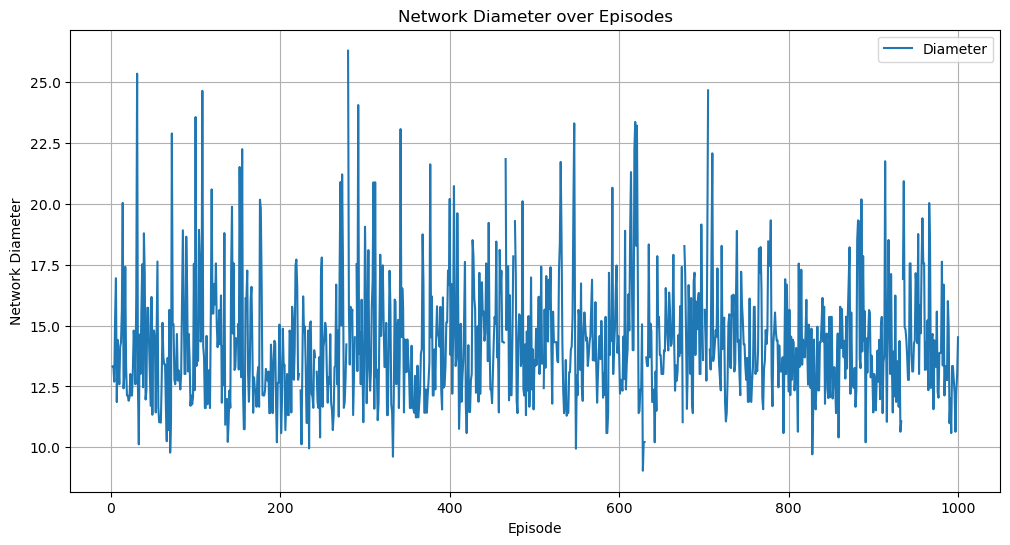

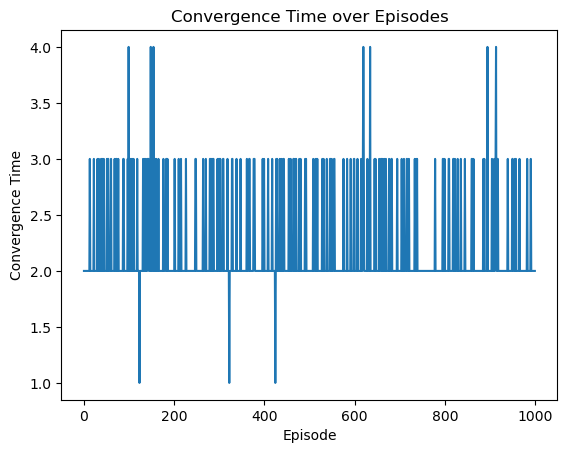

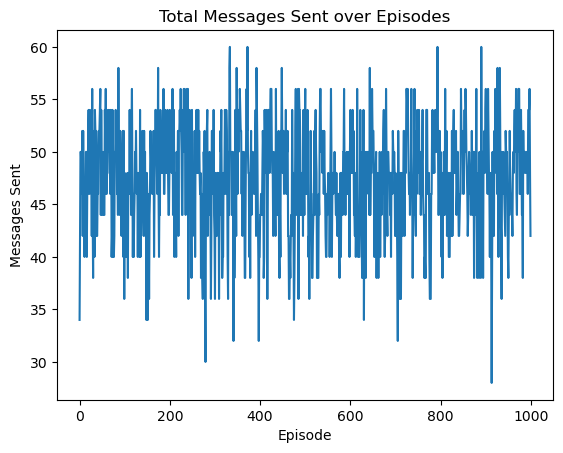

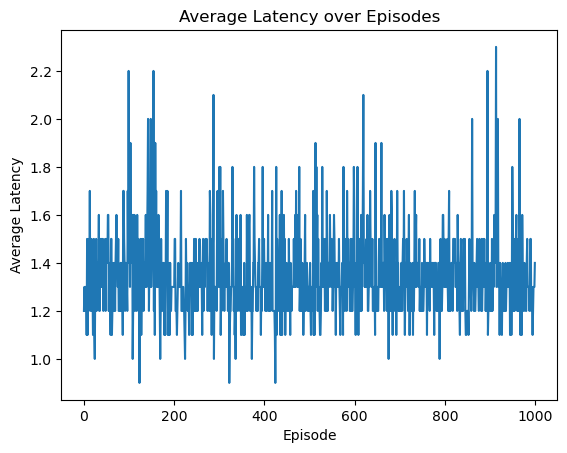

In [15]:
import torch as th
# def select_action(observation, agent_id, max_connections):
#     # 获取延迟信息
#     latencies = observation['latencies']
#     agent_index = int(agent_id.split('_')[1])
#     # 排除自身
#     possible_indices = np.arange(len(latencies))
#     possible_indices = possible_indices[possible_indices != agent_index]
#     # 策略：选择延迟最小的前 max_connections 个节点
#     sorted_indices = possible_indices[np.argsort(latencies[possible_indices])]
#     selected_indices = sorted_indices[:max_connections]
#     action = np.zeros(len(latencies), dtype=np.int32)
#     action[selected_indices] = 1
#     return action

def select_action(observation, agent_id, max_connections):
    # 获取当前连接状态和延迟信息
    connections = observation['connections']
    latencies = observation['latencies']
    agent_index = int(agent_id.split('_')[1])
    # 获取当前已有的邻居索引
    current_neighbors = np.where(connections == 1)[0]
    # 随机决定要移除的邻居数量（可以是0到当前邻居数量）
    num_to_drop = np.random.randint(0, len(current_neighbors)+1)
    # 随机选择要移除的邻居
    if num_to_drop > 0:
        neighbors_to_drop = np.random.choice(current_neighbors, size=num_to_drop, replace=False)
    else:
        neighbors_to_drop = np.array([], dtype=int)
    # 从当前邻居中移除选定的邻居
    new_neighbors = np.setdiff1d(current_neighbors, neighbors_to_drop)
    # 计算还可以连接的邻居数量
    remaining_slots = max_connections - len(new_neighbors)
    if remaining_slots > 0:
        # 获取未连接的节点索引（排除自身和已连接的节点）
        possible_indices = np.arange(len(latencies))
        possible_indices = np.setdiff1d(possible_indices, np.append(new_neighbors, agent_index))
        # 随机选择新的节点进行连接
        num_new_connections = np.random.randint(0, remaining_slots+1)
        if num_new_connections > 0 and len(possible_indices) > 0:
            new_connections = np.random.choice(possible_indices, size=min(num_new_connections, len(possible_indices)), replace=False)
        else:
            new_connections = np.array([], dtype=int)
    else:
        new_connections = np.array([], dtype=int)
    # 更新动作
    action = np.zeros(len(latencies), dtype=np.int32)
    action[new_neighbors] = 1  # 保持未被移除的邻居连接
    action[new_connections] = 1  # 添加新的连接
    return action


seed = 1
th.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
# env = P2PNeighborSelectionEnv(n_agents=10)
# observations = env.reset()

# for episode in range(1000):  # 假设运行10个回合
#     actions = {}
#     for agent in env.agents:
#         actions[agent] = select_action(observations[agent], agent, env.max_connections)
#     observations, rewards, dones, infos = env.step(actions)
#     # 输出当前回合的奖励和网络直径
#     print(f"Episode {episode+1}, Reward: {list(rewards.values())[0]:.2f}, Diameter: {infos[agent]['diameter']:.2f}")
#     # 可视化网络
#     # env.render()

import matplotlib.pyplot as plt
import numpy as np

env = P2PNeighborSelectionEnv(n_agents=10)
observations = env.reset()

diameters = []  # 用于存储每个回合的直径
convergence_times = []
messages_sents = []
average_latencies = []
for episode in range(1000):  # 运行1000个回合
    actions = {}
    for agent in env.agents:
        actions[agent] = select_action(observations[agent], agent, env.max_connections)
    observations, rewards, dones, infos = env.step(actions)
    # 获取当前回合的直径
    diameter = infos[env.agents[0]]['diameter']
    diameters.append(diameter)
    # 在训练循环中，选择一个源节点进行消息传播模拟
    source_agent = random.choice(env.agents)
    gossip_metrics = env.simulate_gossip(source_agent)
    # 记录和输出评估指标
    convergence_times.append(gossip_metrics['convergence_time'])
    messages_sents.append(gossip_metrics['messages_sent'])
    average_latencies.append(gossip_metrics['average_latency'])
    # 输出当前回合的奖励和网络直径（每100个回合输出一次）
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1}, Reward: {list(rewards.values())[0]:.2f}, Diameter: {diameter:.2f}")
    # 可视化网络（可选）
    # env.render()

# 绘制直径与回合数的关系图
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(diameters) + 1), diameters, label='Diameter')
plt.xlabel('Episode')
plt.ylabel('Network Diameter')
plt.title('Network Diameter over Episodes')
plt.legend()
plt.grid(True)
plt.show()

# 绘制收敛时间与回合数的关系图
plt.figure()
plt.plot(convergence_times)
plt.xlabel('Episode')
plt.ylabel('Convergence Time')
plt.title('Convergence Time over Episodes')
plt.show()

# 绘制消息开销与回合数的关系图
plt.figure()
plt.plot(messages_sents)
plt.xlabel('Episode')
plt.ylabel('Messages Sent')
plt.title('Total Messages Sent over Episodes')
plt.show()

# 绘制平均延迟与回合数的关系图
plt.figure()
plt.plot(average_latencies)
plt.xlabel('Episode')
plt.ylabel('Average Latency')
plt.title('Average Latency over Episodes')
plt.show()


# # 平滑曲线（可选）
# def moving_average(data, window_size):
#     return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# window_size = 10  # 移动平均窗口大小
# smoothed_diameters = moving_average(diameters, window_size)

# # 绘制平滑后的曲线
# plt.figure(figsize=(12, 6))
# plt.plot(range(window_size, len(diameters) + 1), smoothed_diameters, label='Smoothed Diameter', color='orange')
# plt.xlabel('Episode')
# plt.ylabel('Network Diameter')
# plt.title('Smoothed Network Diameter over Episodes')
# plt.legend()
# plt.grid(True)
# plt.show()